# 01 — Data Loading & Cleaning

This notebook ingests all nine raw Olist CSV files, examines their structure,
joins them into a single order-level master table, applies cleaning rules,
engineers cohort and time features, and saves the result as Parquet for use
in every downstream notebook.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

from src.data_processing import (
    load_olist_data, build_master_table, cast_dtypes,
    clean_master_table, add_time_features, add_order_level_features,
    validate_data, save_processed,
)

DATA_DIR  = Path('../data/raw')
PROC_PATH = Path('../data/processed/orders_master.parquet')
FIG_DIR   = Path('../outputs/figures')
TBL_DIR   = Path('../outputs/tables')

for d in (PROC_PATH.parent, FIG_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.4f}'.format)
print('Setup complete.')

Setup complete.


## 1. Load Data

We read all nine Olist CSV files into a dictionary of DataFrames keyed by table name.
Nothing is joined yet — this step is purely about getting the raw data into memory
and confirming every file loaded without errors.

In [2]:
dfs = load_olist_data(DATA_DIR)

shape_summary = pd.DataFrame(
    [(name, df.shape[0], df.shape[1]) for name, df in dfs.items()],
    columns=['table', 'rows', 'cols'],
).sort_values('rows', ascending=False).reset_index(drop=True)

print(f'Loaded {len(dfs)} tables\n')
print(shape_summary.to_string(index=False))

Loaded 9 tables

               table    rows  cols
         geolocation 1000163     5
         order_items  112650     7
      order_payments  103886     5
              orders   99441     8
           customers   99441     5
       order_reviews   99224     7
            products   32951     9
             sellers    3095     4
category_translation      71     2


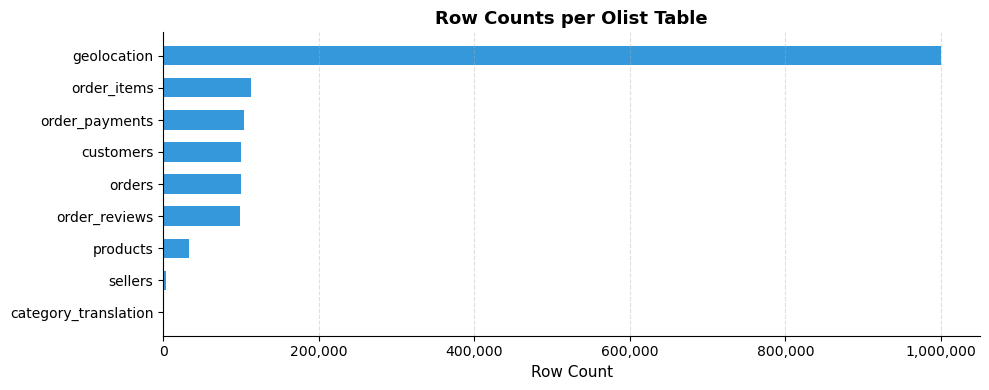

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
s = shape_summary.sort_values('rows')
ax.barh(s['table'], s['rows'], color='#3498db', edgecolor='none', height=0.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('Row Count', fontsize=11)
ax.set_title('Row Counts per Olist Table', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_table_row_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Explore Schemas

Before joining anything we inspect column names, data types, and null rates for each
table. This tells us which columns need type-casting after the join, where missing
values will appear, and whether the join keys look consistent across tables.

In [4]:
# Dtypes and head for the four most important tables
for name in ['orders', 'order_items', 'order_payments', 'customers']:
    df = dfs[name]
    print(f'\n{"-"*55}')
    print(f'  {name}  ({df.shape[0]:,} rows x {df.shape[1]} cols)')
    print(f'{"-"*55}')
    display(df.dtypes.rename('dtype').to_frame().T)
    display(df.head(3))


-------------------------------------------------------
  orders  (99,441 rows x 8 cols)
-------------------------------------------------------


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
dtype,object,object,object,object,object,object,object,object


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



-------------------------------------------------------
  order_items  (112,650 rows x 7 cols)
-------------------------------------------------------


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
dtype,object,int64,object,object,object,float64,float64


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
dtype,object,int64,object,int64,float64


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.3300
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.3900
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.7100



-------------------------------------------------------
  customers  (99,441 rows x 5 cols)
-------------------------------------------------------


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
dtype,object,object,int64,object,object


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [5]:
# Null rates across all tables — save as a reference table
null_rows = []
for name, df in dfs.items():
    for col, rate in (df.isnull().mean() * 100).items():
        if rate > 0:
            null_rows.append({'table': name, 'column': col, 'null_pct': round(rate, 2)})

null_summary = (
    pd.DataFrame(null_rows)
    .sort_values(['table', 'null_pct'], ascending=[True, False])
    .reset_index(drop=True)
)

null_summary.to_csv(TBL_DIR / '01_null_rates.csv', index=False)
print(f'Saved → {TBL_DIR / "01_null_rates.csv"}')
null_summary

Saved → ../outputs/tables/01_null_rates.csv


,table,column,null_pct
0,order_reviews,review_comment_title,88.3400
1,order_reviews,review_comment_message,58.7000
2,orders,order_delivered_customer_date,2.9800
3,orders,order_delivered_carrier_date,1.7900
4,orders,order_approved_at,0.1600
5,products,product_category_name,1.8500
6,products,product_name_lenght,1.8500
7,products,product_description_lenght,1.8500
8,products,product_photos_qty,1.8500
9,products,product_weight_g,0.0100


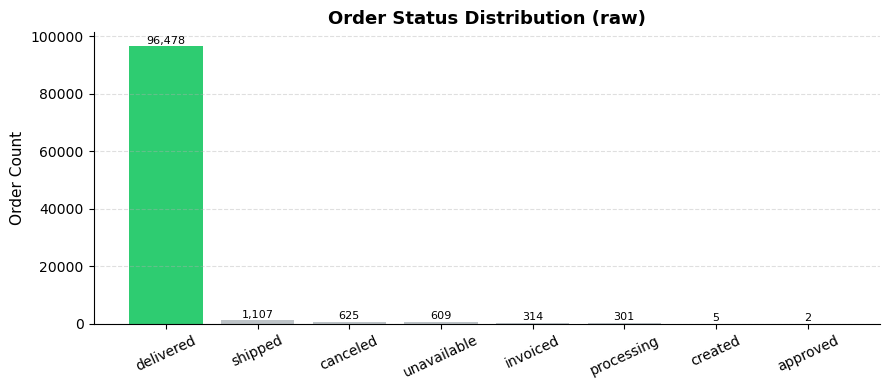

In [6]:
# Order status breakdown — shows how many orders we will drop in cleaning
status_counts = dfs['orders']['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(status_counts.index, status_counts.values,
              color=['#2ecc71' if s == 'delivered' else '#bdc3c7' for s in status_counts.index],
              edgecolor='none')
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 120,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Order Count', fontsize=11)
ax.set_title('Order Status Distribution (raw)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_order_status_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Clean and Validate

We join the nine tables into one flat item-level master table, cast all date columns
to proper datetime types, then apply three cleaning rules: keep only delivered orders,
drop rows with zero or negative revenue, and drop rows missing a purchase timestamp
or customer ID. After cleaning we engineer cohort month, cohort index, and other
time-based features, then collapse the item-level rows to one row per order.
A final `validate_data` call asserts key invariants — unique order IDs, positive
revenue, and non-negative cohort indices — before anything gets written to disk.

In [7]:
# Build and cast
master = build_master_table(dfs)
master = cast_dtypes(master)
print(f'Master table (item-level, pre-clean): {master.shape[0]:,} rows x {master.shape[1]} cols')

Master table (item-level, pre-clean): 113,425 rows x 23 cols


In [8]:
# Track rows dropped at each cleaning step
n0 = len(master)
s1 = master[master['order_status'] == 'delivered']
s2 = s1[(s1['payment_value'] > 0) & (s1['price'] > 0)]
s3 = s2.dropna(subset=['order_purchase_timestamp', 'customer_unique_id'])

drop_log = pd.DataFrame({
    'step':         ['raw master', 'keep delivered only', 'keep valid revenue', 'drop null keys'],
    'rows':         [n0, len(s1), len(s2), len(s3)],
    'rows_dropped': [0, n0 - len(s1), len(s1) - len(s2), len(s2) - len(s3)],
})
drop_log['pct_of_raw'] = (drop_log['rows_dropped'] / n0 * 100).round(2)
drop_log.to_csv(TBL_DIR / '01_cleaning_drop_log.csv', index=False)
print(f'Saved → {TBL_DIR / "01_cleaning_drop_log.csv"}\n')
print(drop_log.to_string(index=False))

Saved → ../outputs/tables/01_cleaning_drop_log.csv

               step   rows  rows_dropped  pct_of_raw
         raw master 113425             0      0.0000
keep delivered only 110197          3228      2.8500
 keep valid revenue 110194             3      0.0000
     drop null keys 110194             0      0.0000


In [9]:
# Apply cleaning, feature engineering, and aggregation
master_clean = clean_master_table(master)
master_clean = add_time_features(master_clean)
orders       = add_order_level_features(master_clean)

print(f'After cleaning   (item-level): {master_clean.shape[0]:,} rows')
print(f'After aggregation (order-level): {orders.shape[0]:,} rows x {orders.shape[1]} cols')
orders.head(3)

After cleaning   (item-level): 110,194 rows
After aggregation (order-level): 96,477 rows x 18 cols


,order_id,customer_unique_id,customer_state,seller_state,order_purchase_timestamp,order_month,cohort_month,cohort_index,order_year,order_dow,order_hour,delivery_days,revenue,payment_installments,item_count,avg_item_price,review_score,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,SP,2017-09-13 08:59:02,2017-09,2017-09,0,2017,2,8,7.0000,72.1900,2.0000,1.0000,58.9000,5.0000,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,SP,2017-04-26 10:53:06,2017-04,2017-04,0,2017,2,10,16.0000,259.8300,3.0000,1.0000,239.9000,4.0000,pet_shop
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,MG,2018-01-14 14:33:31,2018-01,2018-01,0,2018,6,14,7.0000,216.8700,5.0000,1.0000,199.0000,5.0000,furniture_decor


In [10]:
# Validate — raises AssertionError if any check fails
orders = validate_data(orders)
print('All validation checks passed.')

All validation checks passed.


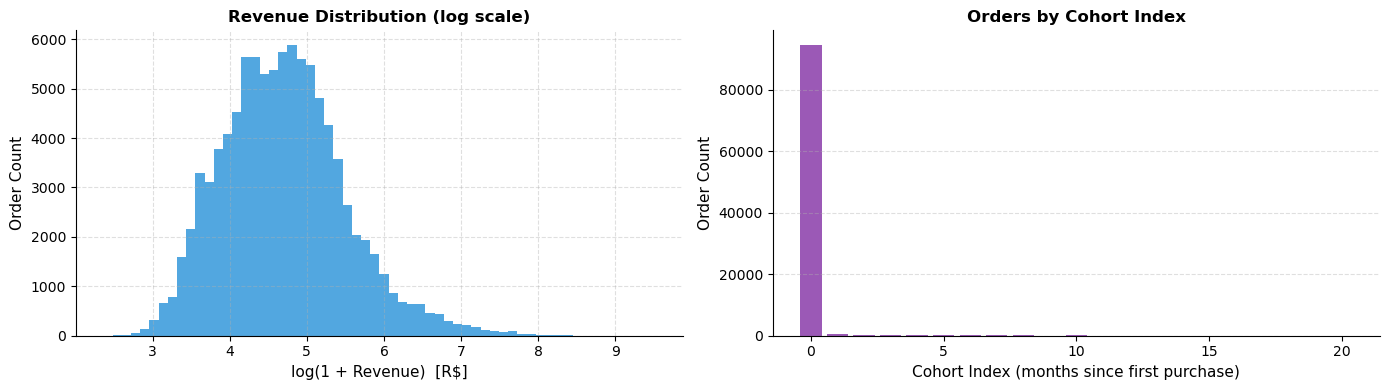

In [11]:
# Revenue and cohort index distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(np.log1p(orders['revenue']), bins=60,
         color='#3498db', edgecolor='none', alpha=0.85)
ax1.set_xlabel('log(1 + Revenue)  [R$]', fontsize=11)
ax1.set_ylabel('Order Count', fontsize=11)
ax1.set_title('Revenue Distribution (log scale)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

cohort_counts = orders['cohort_index'].value_counts().sort_index()
ax2.bar(cohort_counts.index, cohort_counts.values,
        color='#9b59b6', edgecolor='none', width=0.8)
ax2.set_xlabel('Cohort Index (months since first purchase)', fontsize=11)
ax2.set_ylabel('Order Count', fontsize=11)
ax2.set_title('Orders by Cohort Index', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / '01_revenue_and_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

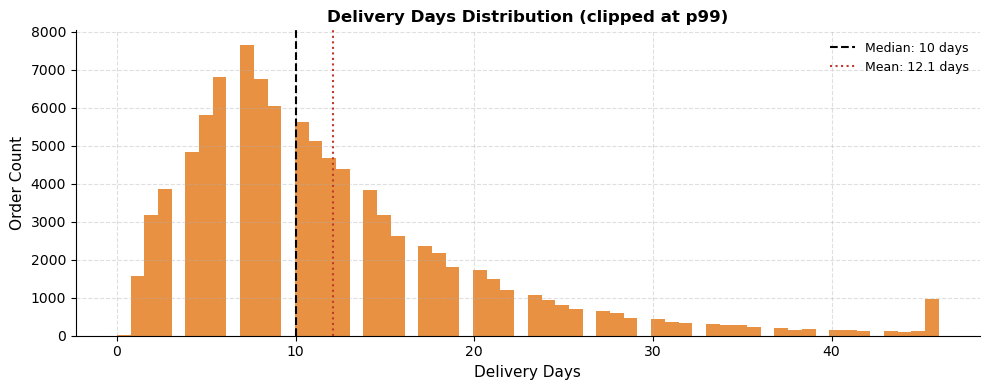

In [12]:
# Delivery days distribution
delivery = orders['delivery_days'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delivery.clip(upper=delivery.quantile(0.99)), bins=60,
        color='#e67e22', edgecolor='none', alpha=0.85)
ax.axvline(delivery.median(), color='black', linestyle='--', linewidth=1.5,
           label=f'Median: {delivery.median():.0f} days')
ax.axvline(delivery.mean(), color='#c0392b', linestyle=':', linewidth=1.5,
           label=f'Mean: {delivery.mean():.1f} days')
ax.set_xlabel('Delivery Days', fontsize=11)
ax.set_ylabel('Order Count', fontsize=11)
ax.set_title('Delivery Days Distribution (clipped at p99)', fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_delivery_days.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Save Processed File

The cleaned, validated, order-level table is written to `data/processed/orders_master.parquet`.
Parquet preserves column dtypes (no silent string/float coercions on re-load), reads faster
than CSV, and takes less disk space — all of which matter as the downstream notebooks
load this file repeatedly. We also save a descriptive stats table and a column summary
to `outputs/tables/` for quick reference.

In [13]:
save_processed(orders, PROC_PATH)

size_kb = PROC_PATH.stat().st_size / 1024
print(f'Saved  →  {PROC_PATH}')
print(f'Size   :  {size_kb:,.1f} KB')
print(f'Rows   :  {orders.shape[0]:,}')
print(f'Cols   :  {orders.shape[1]}')

saved -> ../data/processed/orders_master.parquet
Saved  →  ../data/processed/orders_master.parquet
Size   :  8,105.5 KB
Rows   :  96,477
Cols   :  18


In [14]:
# Descriptive stats for numeric columns
numeric_cols = ['revenue', 'item_count', 'avg_item_price',
                'payment_installments', 'delivery_days',
                'review_score', 'cohort_index']

desc = (
    orders[numeric_cols]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .T.round(2)
)

desc.to_csv(TBL_DIR / '01_descriptive_stats.csv')
print(f'Saved → {TBL_DIR / "01_descriptive_stats.csv"}')
desc

Saved → ../outputs/tables/01_descriptive_stats.csv


,count,mean,std,min,25%,50%,75%,95%,max
revenue,"96,477.0000",159.8600,218.8100,9.5900,61.8800,105.2800,176.3300,446.3100,"13,664.0800"
item_count,"96,477.0000",1.1400,0.5400,1.0000,1.0000,1.0000,1.0000,2.0000,21.0000
avg_item_price,"96,477.0000",125.2300,189.7000,0.8500,41.9000,79.0000,139.9000,364.0000,"6,735.0000"
payment_installments,"96,477.0000",2.9300,2.7100,0.0000,1.0000,2.0000,4.0000,10.0000,24.0000
delivery_days,"96,469.0000",12.0900,9.5500,0.0000,6.0000,10.0000,15.0000,29.0000,209.0000
review_score,"95,831.0000",4.1600,1.2800,1.0000,4.0000,5.0000,5.0000,5.0000,5.0000
cohort_index,"96,477.0000",0.0900,0.8500,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000


In [15]:
# Column-level summary of the final processed table
col_summary = pd.DataFrame({
    'dtype':    orders.dtypes.astype(str),
    'non_null': orders.notna().sum(),
    'null_pct': (orders.isna().mean() * 100).round(2),
    'n_unique': orders.nunique(),
})

col_summary.to_csv(TBL_DIR / '01_column_summary.csv')
print(f'Saved → {TBL_DIR / "01_column_summary.csv"}')
col_summary

Saved → ../outputs/tables/01_column_summary.csv


,dtype,non_null,null_pct,n_unique
order_id,object,96477,0.0000,96477
customer_unique_id,object,96477,0.0000,93357
customer_state,object,96477,0.0000,27
seller_state,object,96477,0.0000,22
order_purchase_timestamp,datetime64[ns],96477,0.0000,95955
order_month,period[M],96477,0.0000,22
cohort_month,period[M],96477,0.0000,22
cohort_index,int64,96477,0.0000,20
order_year,int32,96477,0.0000,3
order_dow,int32,96477,0.0000,7
